# Analise local de longevidade

Este notebook le todas as planilhas cadastradas em `data/metadata.csv`, calcula indicadores para tabuas de periodo e gera graficos em `outputs/figures`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import K_MAX
from src.data.loaders import load_life_tables_from_metadata, load_metadata
from src.analysis.hazard import add_survival_hazard
from src.analysis.indicators import (
    build_indicators,
    build_milestone_long,
    indicator_correlations,
    indicator_rankings,
    milestone_differences,
)
from src.visualization.plots import (
    plot_benchmark_hazard_gap_vs_chile,
    plot_correlation_heatmap,
    plot_fixed_age_hazards,
    plot_hazard_curves,
    plot_indicator_bars_brazil_regions,
    plot_indicator_heatmap_standardized,
    plot_indicator_rankings,
    plot_indicator_scatter,
    plot_milestone_bars,
    plot_milestone_differences,
    plot_regional_hazard_by_sex,
    plot_regional_hazard_gap_by_sex,
    plot_regional_survival_by_sex,
    plot_sex_hazard_gap_by_region,
    plot_survival_curves,
)

## Planilhas cadastradas

In [2]:
metadata = load_metadata()
metadata

,filename,country,year,sex,label
0,tabua_vida_feminina_nordeste_2025.xlsx,Nordeste (Brasil),2025,Feminino,Nordeste (Brasil) - Feminino
1,tabua_vida_feminina_chile_2023.xlsx,Chile,2023,Feminino,Chile - Feminino
2,tabua_vida_masculina_nordeste_2025.xlsx,Nordeste (Brasil),2025,Masculino,Nordeste (Brasil) - Masculino
3,tabua_vida_masculina_chile_2023.xlsx,Chile,2023,Masculino,Chile - Masculino
4,tabua_vida_feminina_norte_2025.xlsx,Norte (Brasil),2025,Feminino,Norte (Brasil) - Feminino
5,tabua_vida_masculina_norte_2025.xlsx,Norte (Brasil),2025,Masculino,Norte (Brasil) - Masculino


## Indicadores

In [3]:
raw = load_life_tables_from_metadata()
life_tables = add_survival_hazard(raw)
indicators = build_indicators(life_tables, k_max=K_MAX)
milestones = build_milestone_long(life_tables, k_max=K_MAX)

indicators

,country,year,age_min,age_max,H_max,H_60,H_70,H_80,H_90,H_100,...,modal_age,median_age,x_H1,x_H2,x_H3,x_H4,x_H5,x_H6,x_H7,x_H8
0,Chile - Feminino,2023,0.0,90.0,1.071908,0.064922,0.148925,0.375851,1.071908,NaN,...,87.5,85.688245,89.159684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chile - Masculino,2023,0.0,90.0,1.367944,0.110327,0.239530,0.548971,1.367944,NaN,...,82.5,82.361327,86.202682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Nordeste (Brasil) - Feminino,2025,0.0,90.0,1.330084,0.104435,0.208108,0.467868,1.330084,NaN,...,87.5,83.880125,87.059204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Nordeste (Brasil) - Masculino,2025,0.0,90.0,1.845215,0.226562,0.405321,0.785781,1.845215,NaN,...,87.5,78.174673,82.827433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Norte (Brasil) - Feminino,2025,0.0,90.0,1.374586,0.105360,0.210844,0.483792,1.374586,NaN,...,87.5,83.492009,86.745260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Norte (Brasil) - Masculino,2025,0.0,90.0,1.853139,0.208960,0.380264,0.772962,1.853139,NaN,...,87.5,78.496718,82.902316,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Correlações e rankings

In [4]:
correlations = indicator_correlations(indicators)
rankings = indicator_rankings(indicators)

correlations

,H_max,H_60,H_70,H_80,H_90,x_H1,e0_approx,e50_approx,modal_age,median_age
H_max,1.000000,0.885714,0.885714,0.885714,1.000000,-0.885714,-0.885714,-0.885714,0.130931,-0.885714
H_60,0.885714,1.000000,1.000000,1.000000,0.885714,-1.000000,-1.000000,-1.000000,-0.130931,-1.000000
H_70,0.885714,1.000000,1.000000,1.000000,0.885714,-1.000000,-1.000000,-1.000000,-0.130931,-1.000000
H_80,0.885714,1.000000,1.000000,1.000000,0.885714,-1.000000,-1.000000,-1.000000,-0.130931,-1.000000
H_90,1.000000,0.885714,0.885714,0.885714,1.000000,-0.885714,-0.885714,-0.885714,0.130931,-0.885714
x_H1,-0.885714,-1.000000,-1.000000,-1.000000,-0.885714,1.000000,1.000000,1.000000,0.130931,1.000000
e0_approx,-0.885714,-1.000000,-1.000000,-1.000000,-0.885714,1.000000,1.000000,1.000000,0.130931,1.000000
e50_approx,-0.885714,-1.000000,-1.000000,-1.000000,-0.885714,1.000000,1.000000,1.000000,0.130931,1.000000
modal_age,0.130931,-0.130931,-0.130931,-0.130931,0.130931,0.130931,0.130931,0.130931,1.000000,0.130931
median_age,-0.885714,-1.000000,-1.000000,-1.000000,-0.885714,1.000000,1.000000,1.000000,0.130931,1.000000


In [5]:
rankings

,country,year,H_max,H_90,x_H1,e0_approx,median_age,rank_H_max,rank_H_90,rank_x_H1,rank_e0_approx,rank_median_age
0,Chile - Feminino,2023,1.071908,1.071908,89.159684,81.042863,85.688245,1.0,1.0,1.0,1.0,1.0
1,Chile - Masculino,2023,1.367944,1.367944,86.202682,77.750274,82.361327,3.0,3.0,4.0,4.0,4.0
2,Nordeste (Brasil) - Feminino,2025,1.330084,1.330084,87.059204,78.416875,83.880125,2.0,2.0,2.0,2.0,2.0
3,Nordeste (Brasil) - Masculino,2025,1.845215,1.845215,82.827433,71.936850,78.174673,5.0,5.0,6.0,6.0,6.0
4,Norte (Brasil) - Feminino,2025,1.374586,1.374586,86.745260,78.080294,83.492009,4.0,4.0,3.0,3.0,3.0
5,Norte (Brasil) - Masculino,2025,1.853139,1.853139,82.902316,72.280232,78.496718,6.0,6.0,5.0,5.0,5.0


## Visao geral

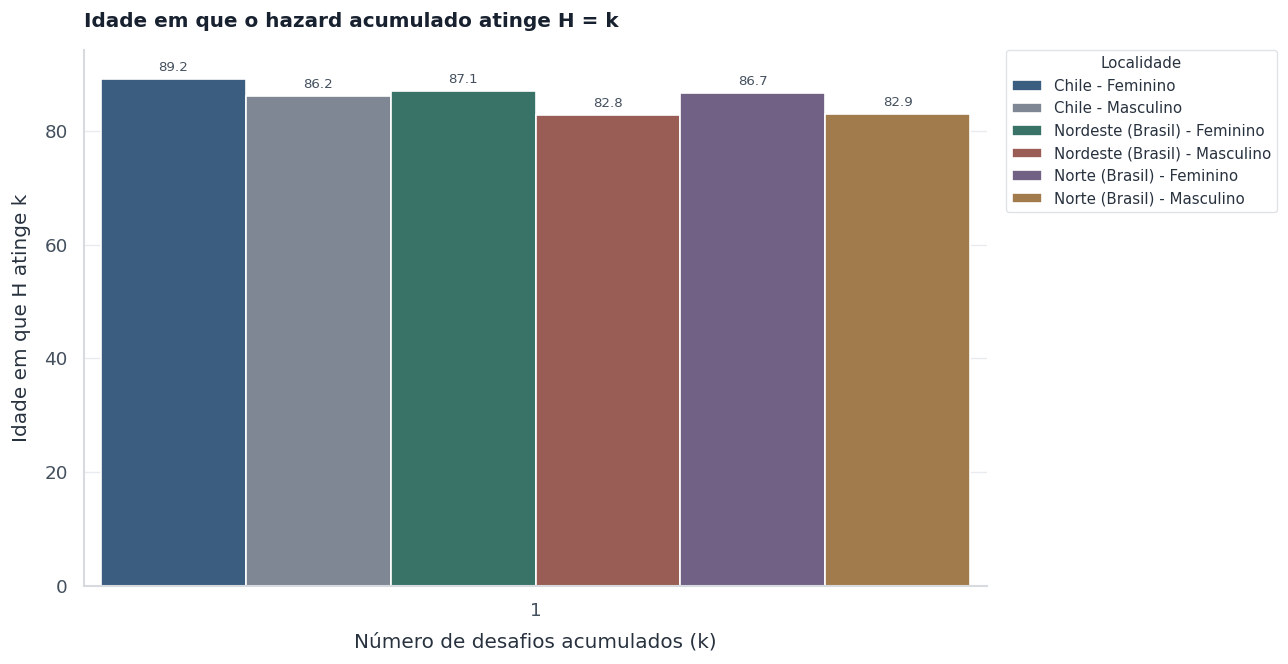

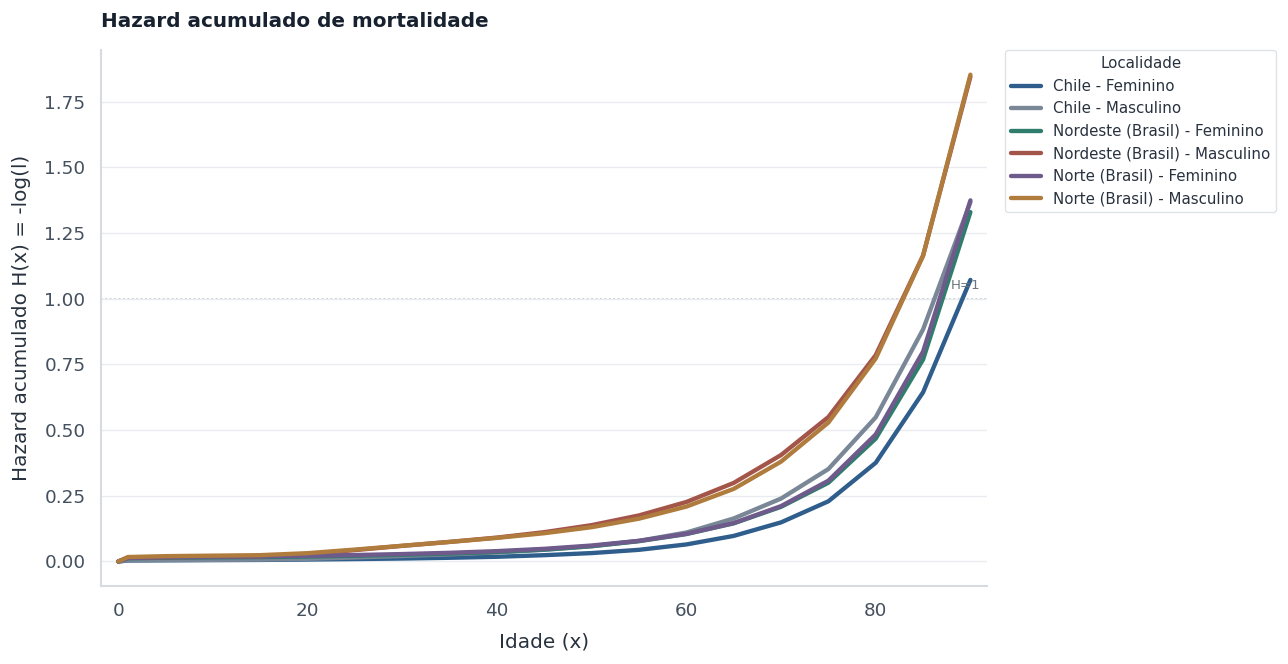

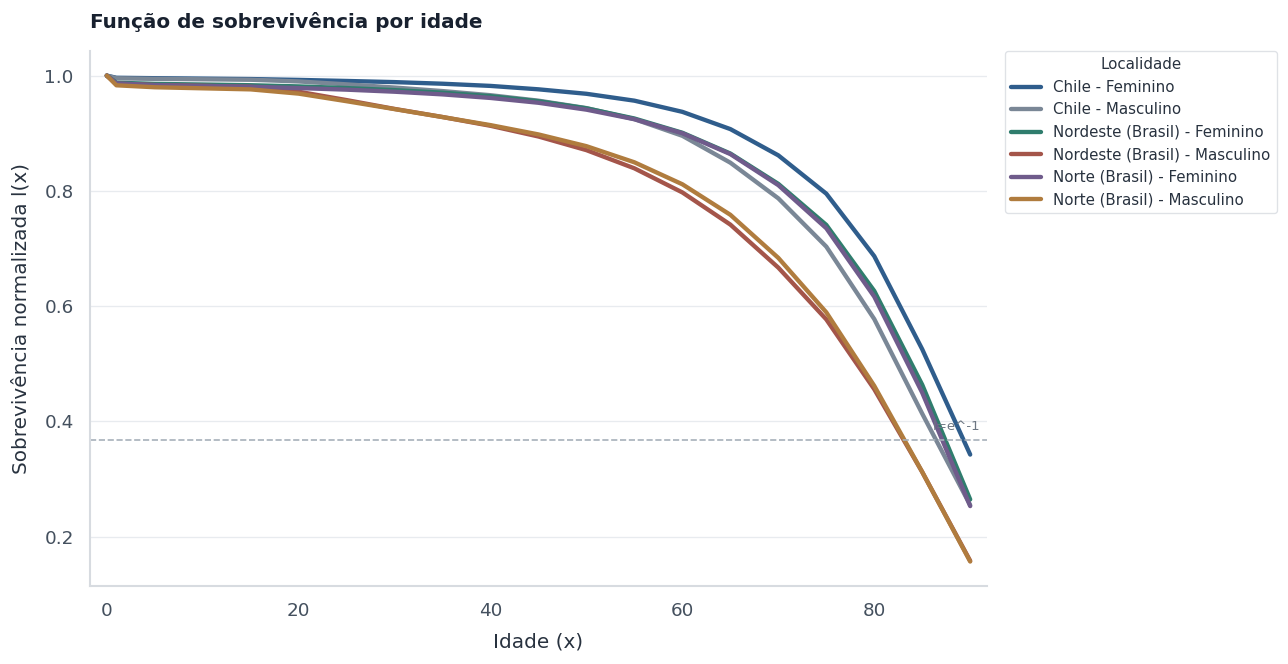

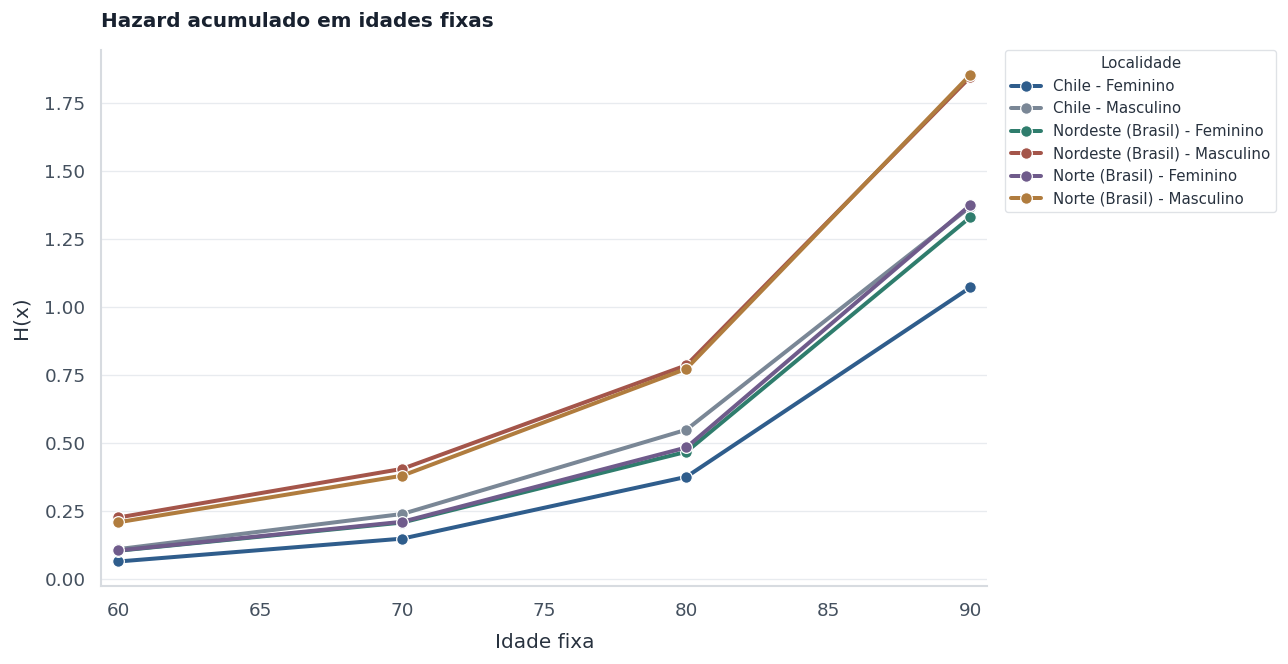

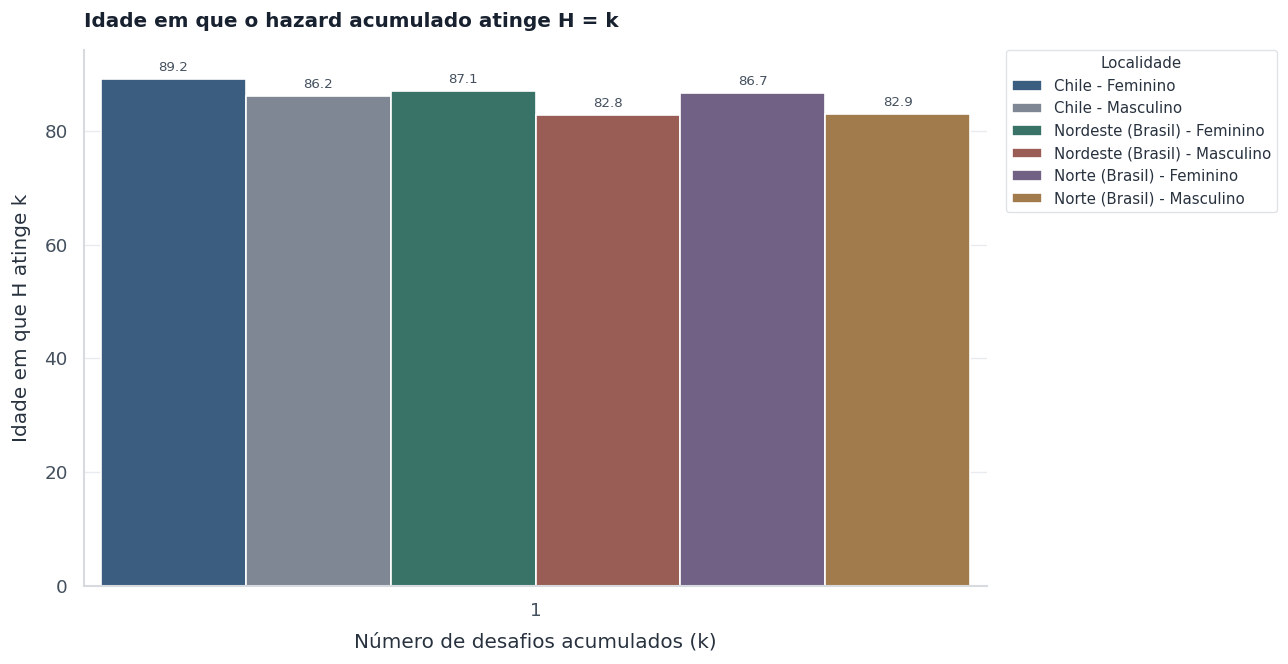

In [6]:
plot_hazard_curves(life_tables)
plot_survival_curves(life_tables)
plot_fixed_age_hazards(indicators)
plot_milestone_bars(milestones)

## Norte vs Nordeste

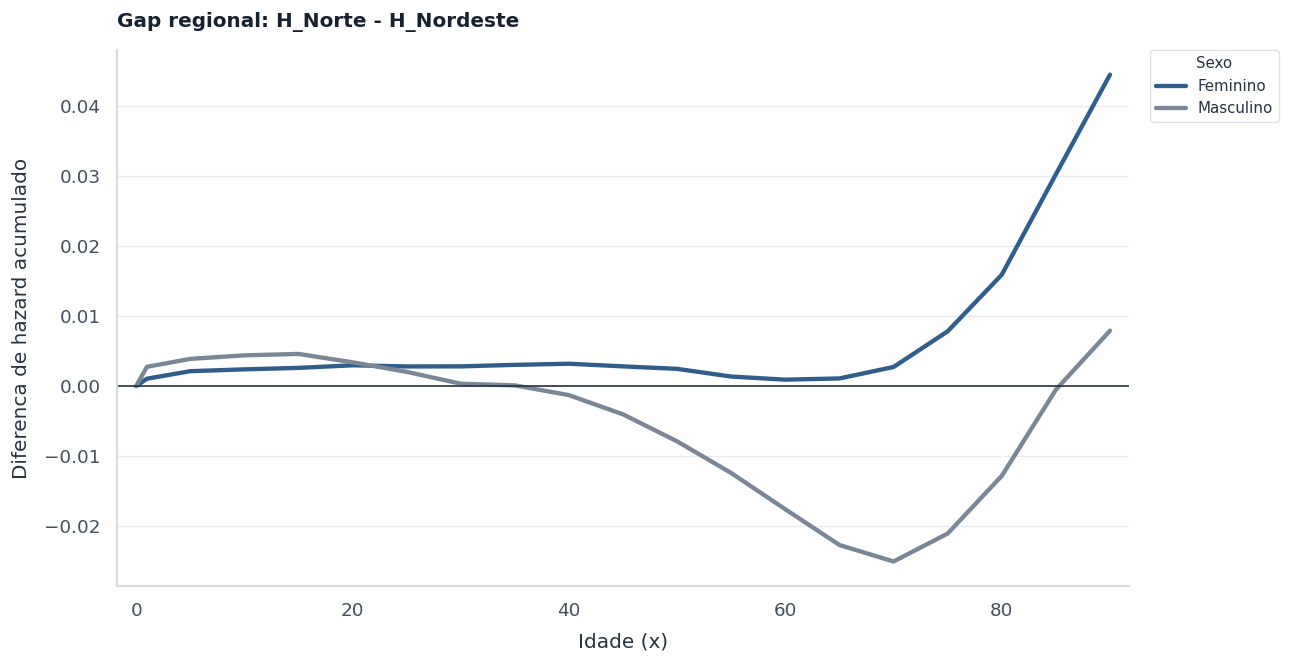

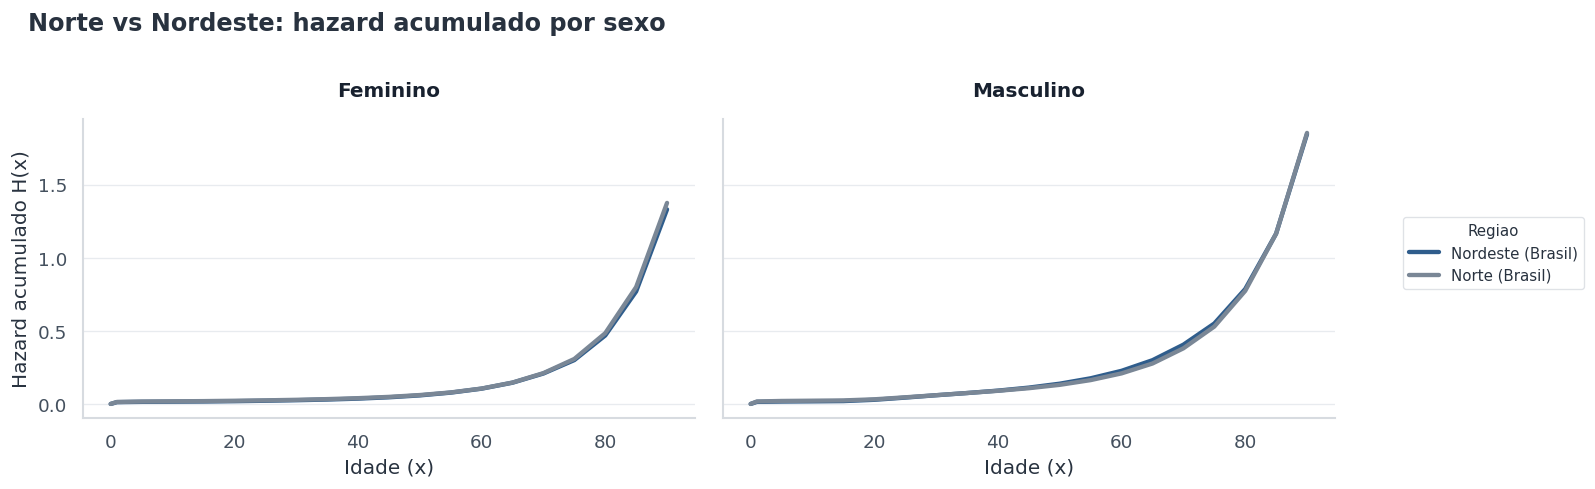

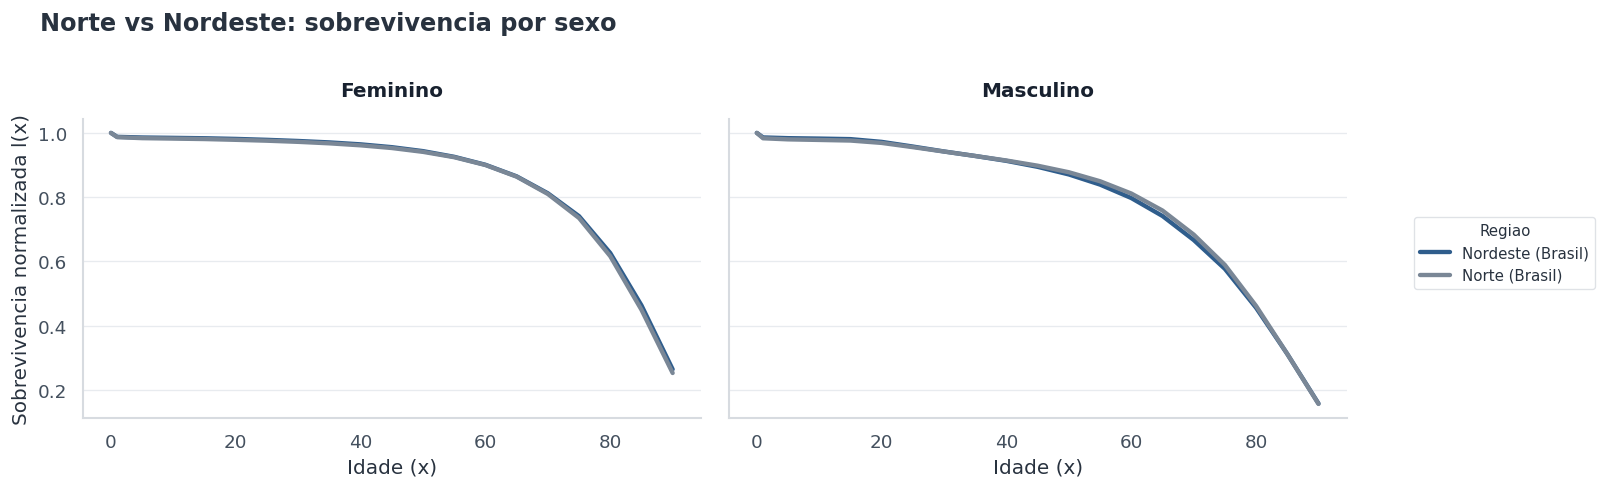

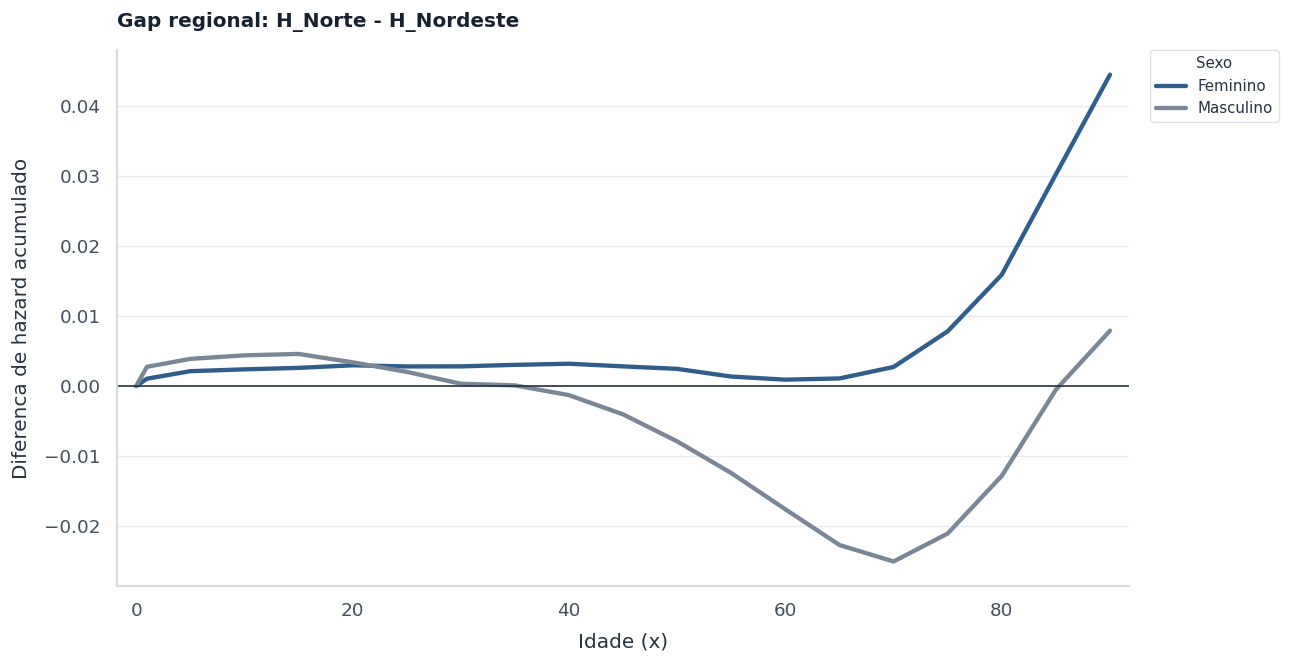

In [7]:
plot_regional_hazard_by_sex(life_tables)
plot_regional_survival_by_sex(life_tables)
plot_regional_hazard_gap_by_sex(life_tables)

## Diferencas por sexo nas regioes brasileiras

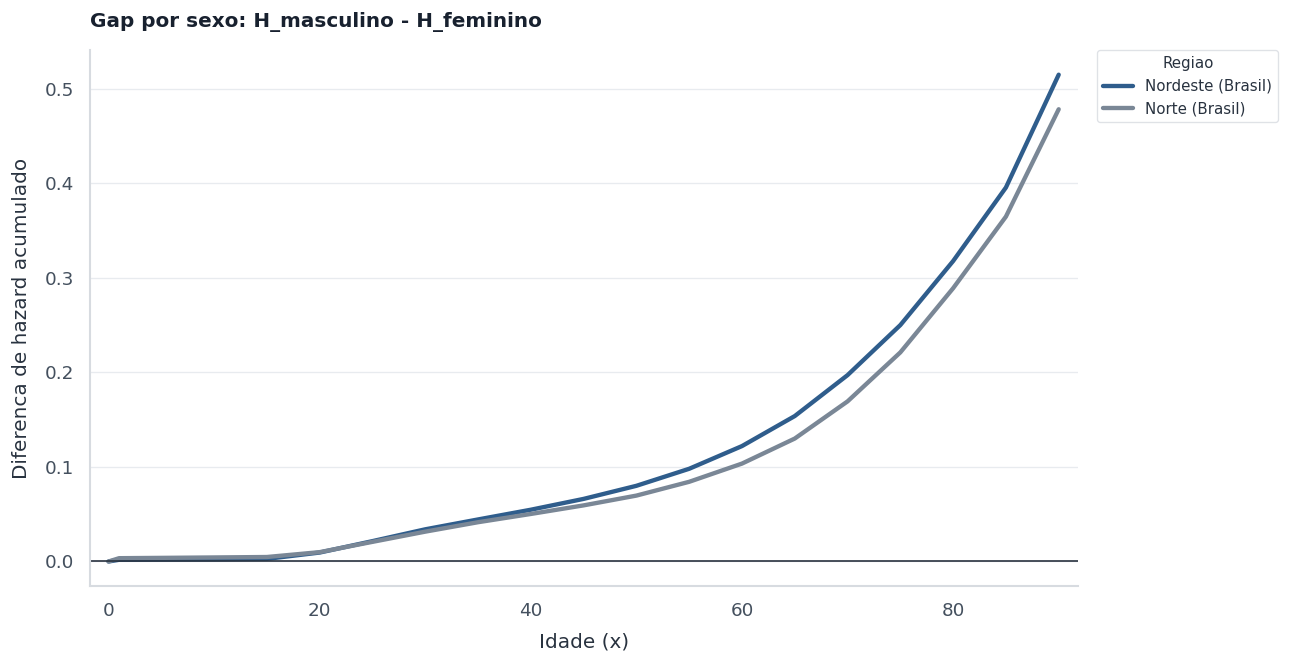

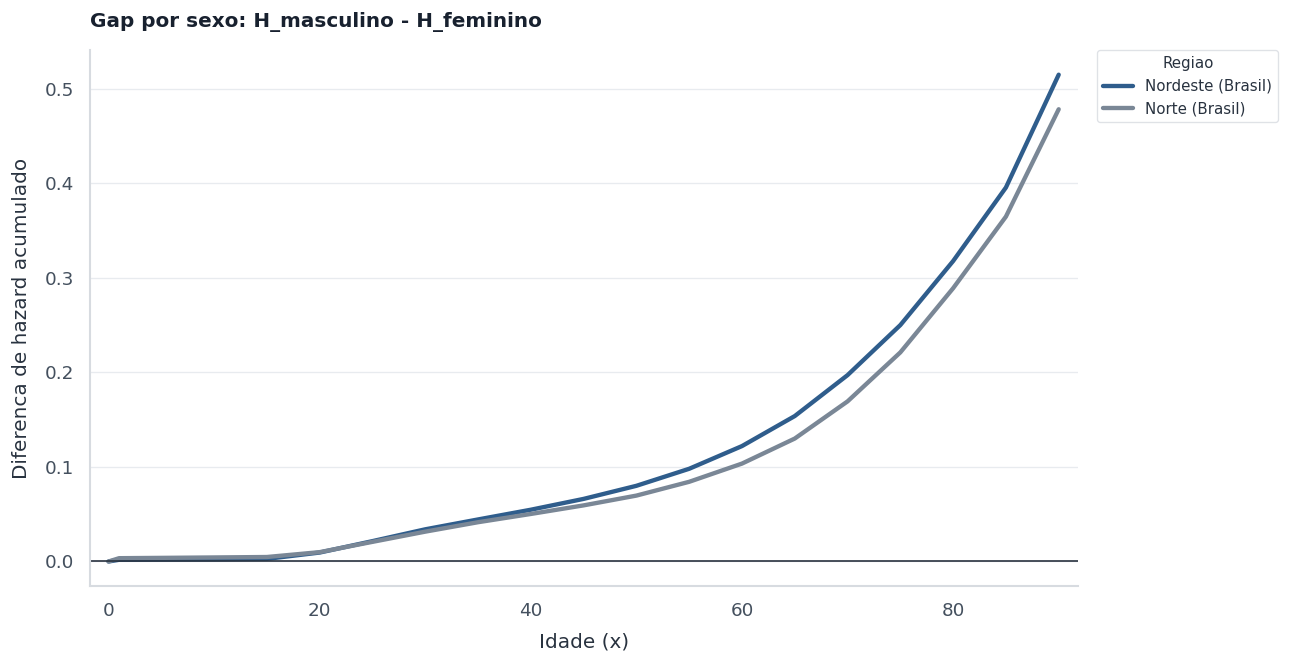

In [8]:
plot_sex_hazard_gap_by_region(life_tables)

## Chile como benchmark externo

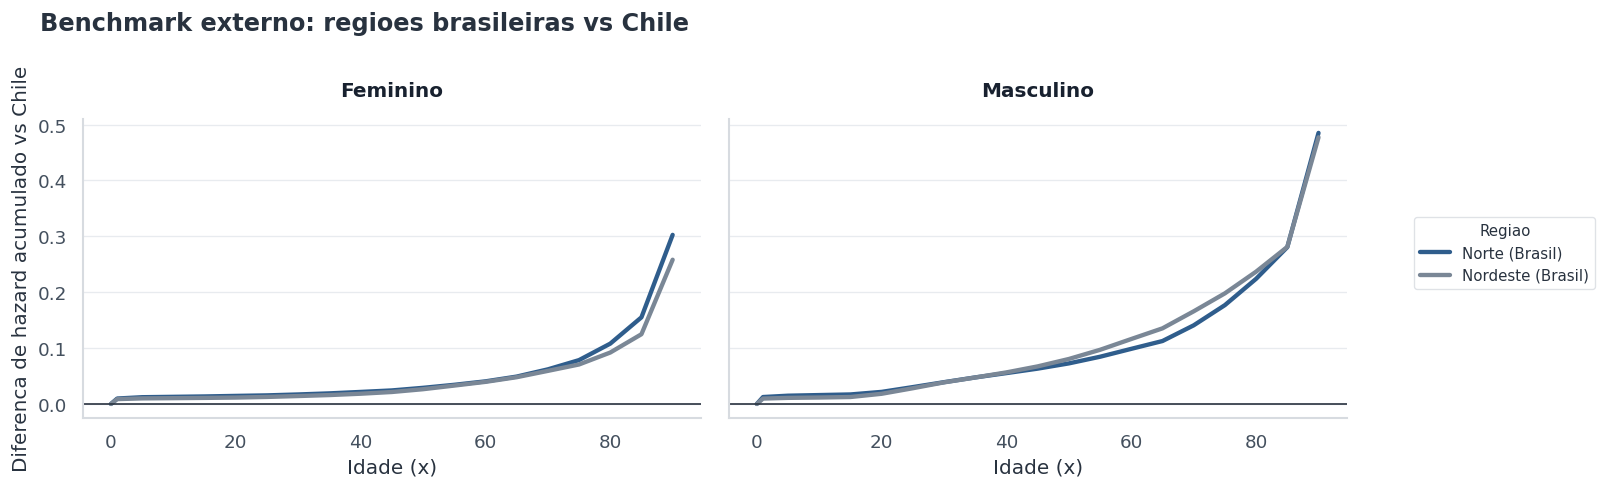

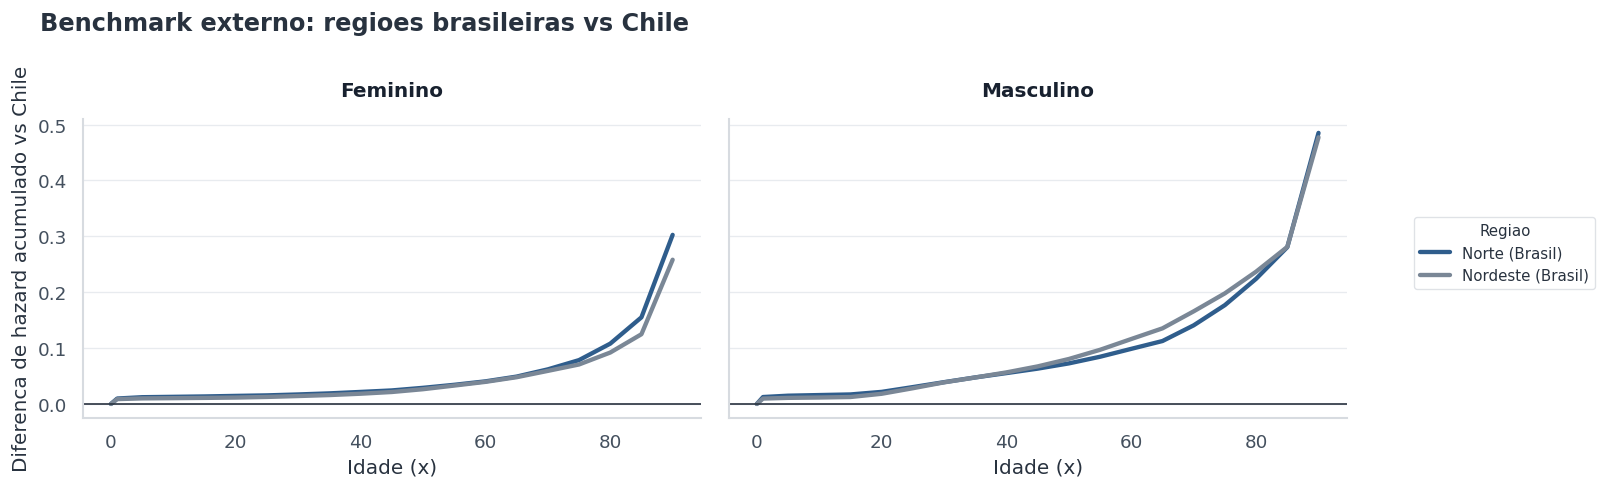

In [9]:
plot_benchmark_hazard_gap_vs_chile(life_tables)

## Resumo de indicadores

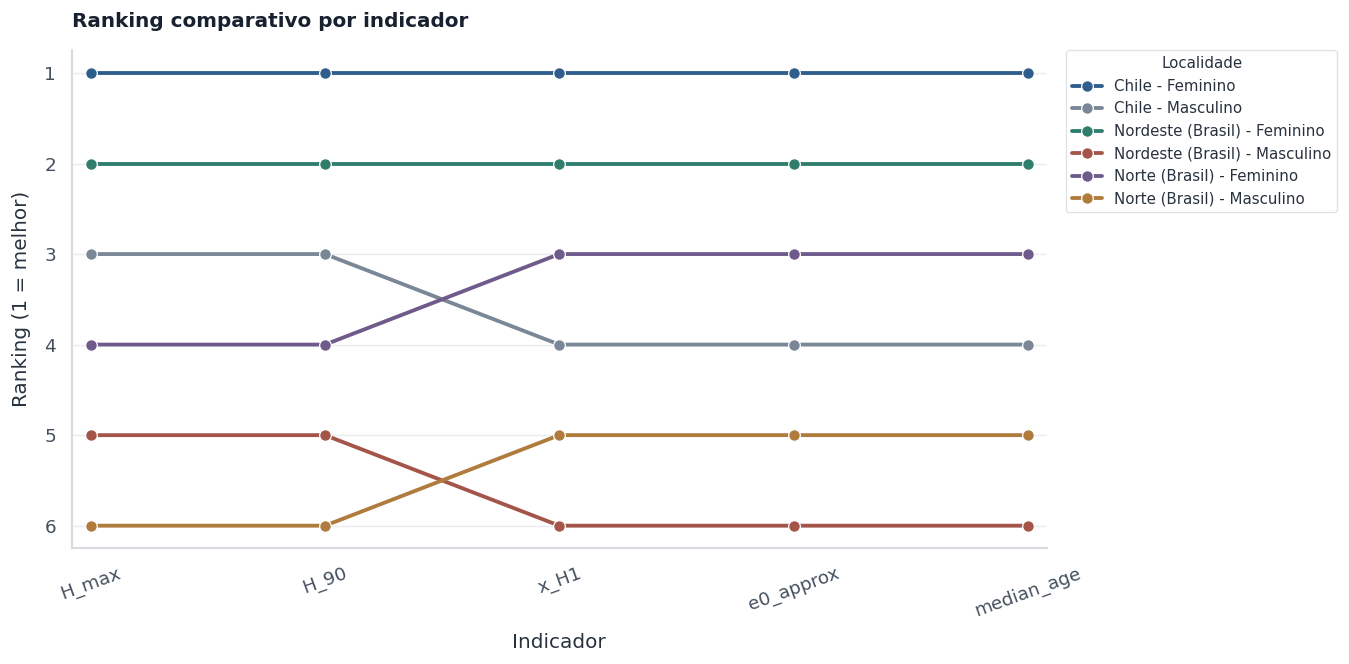

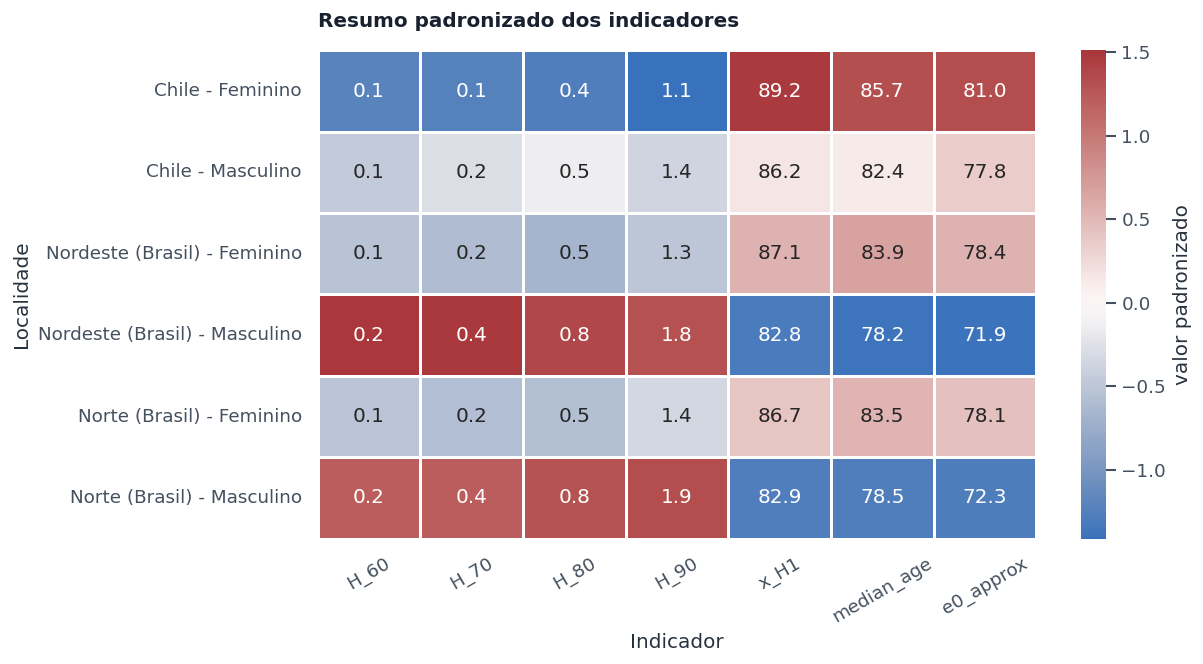

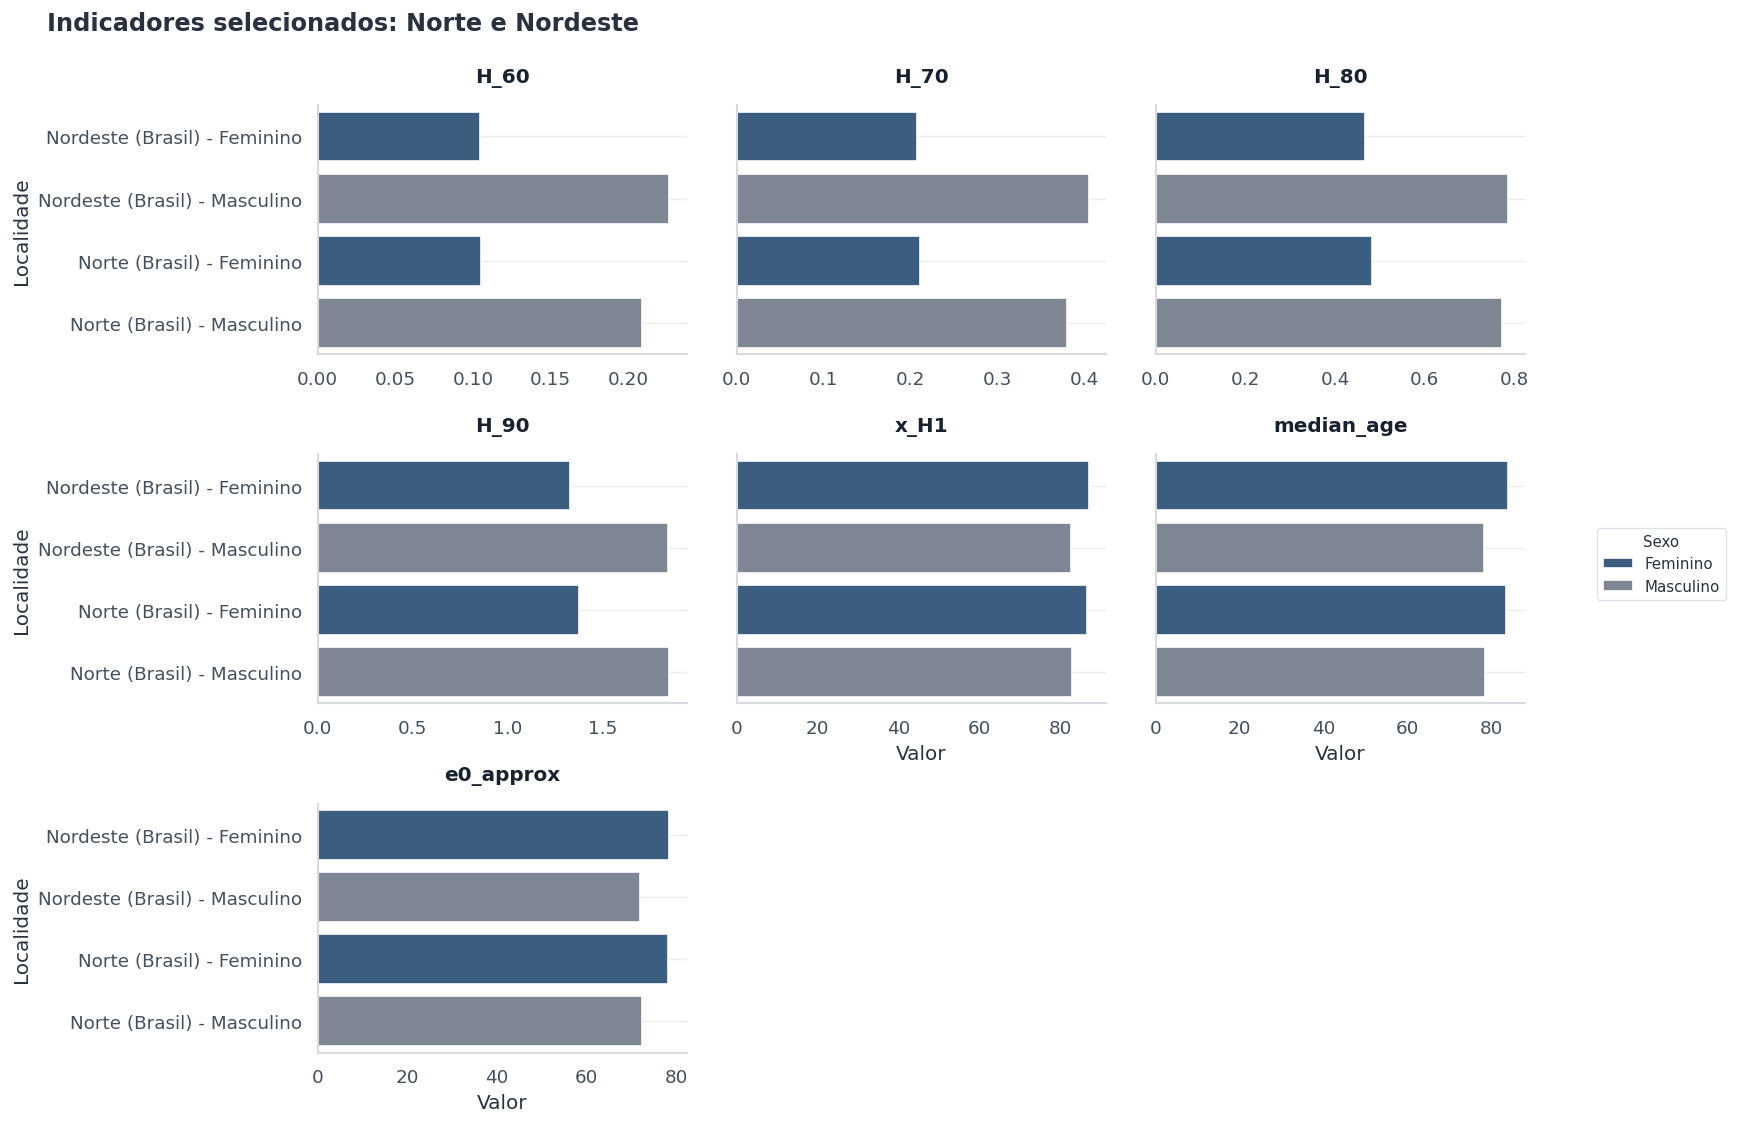

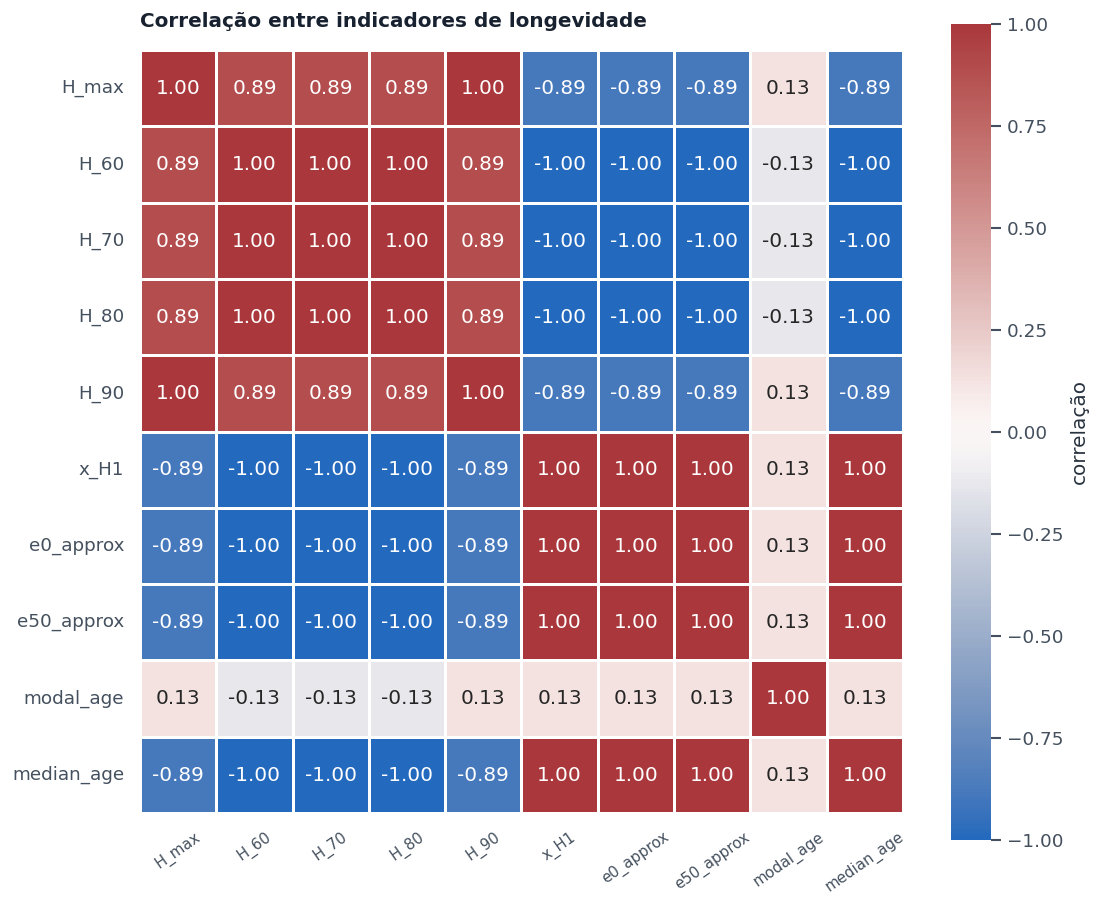

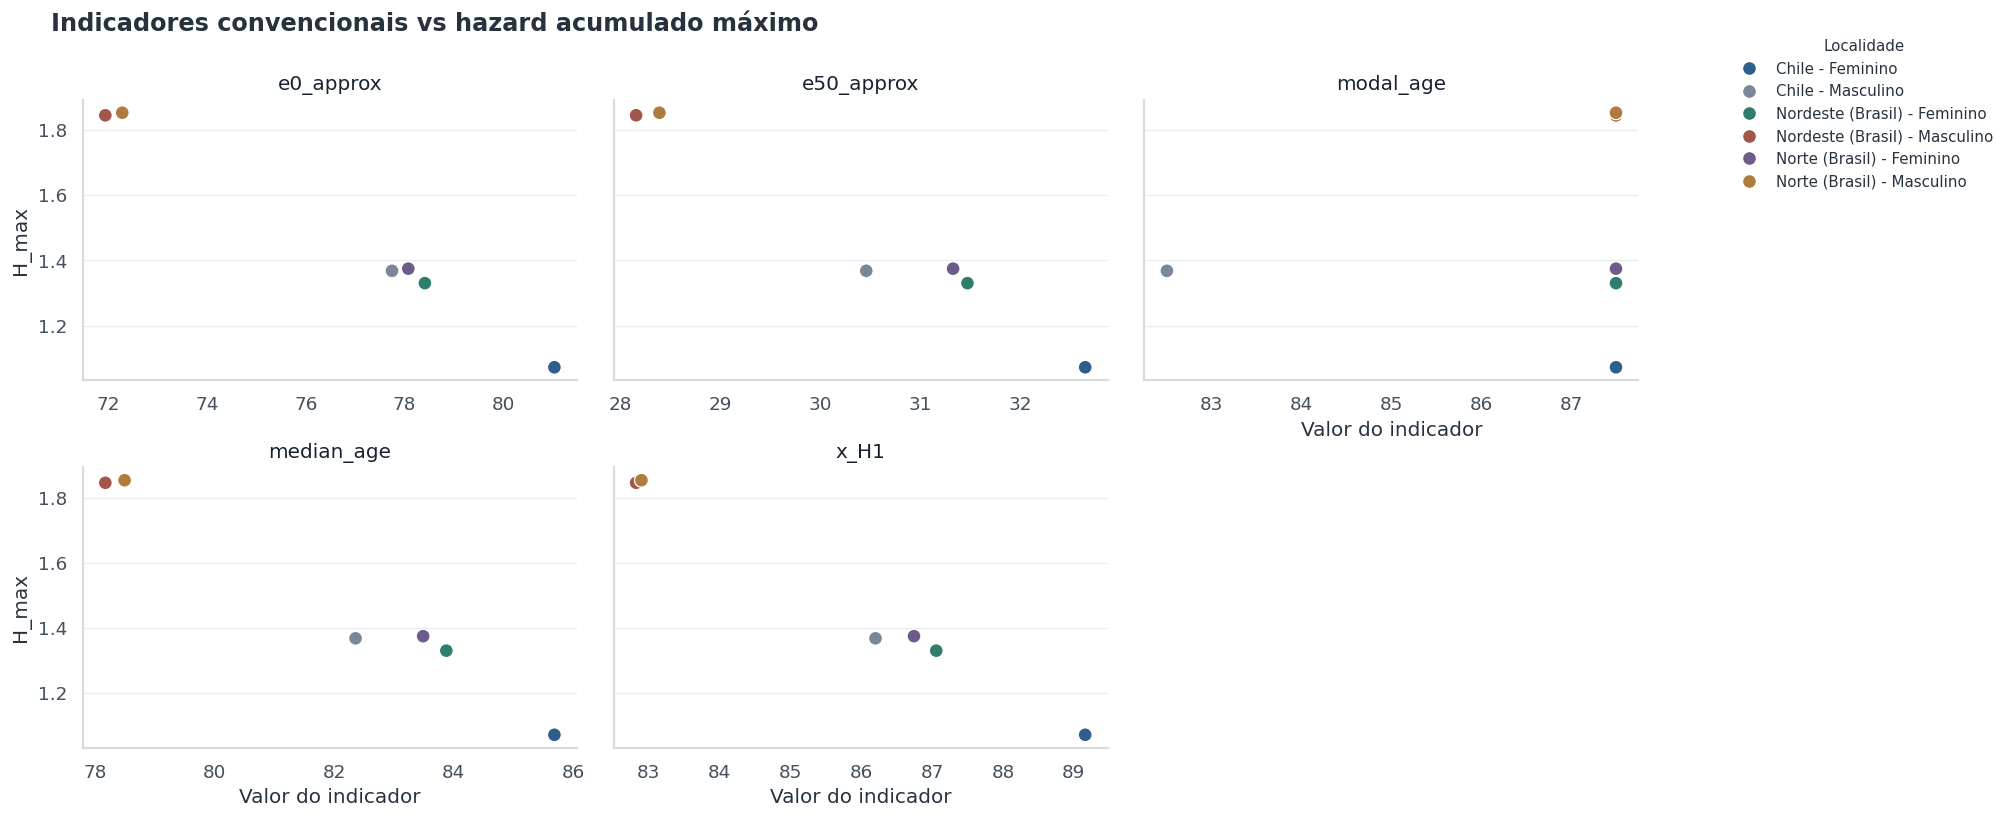

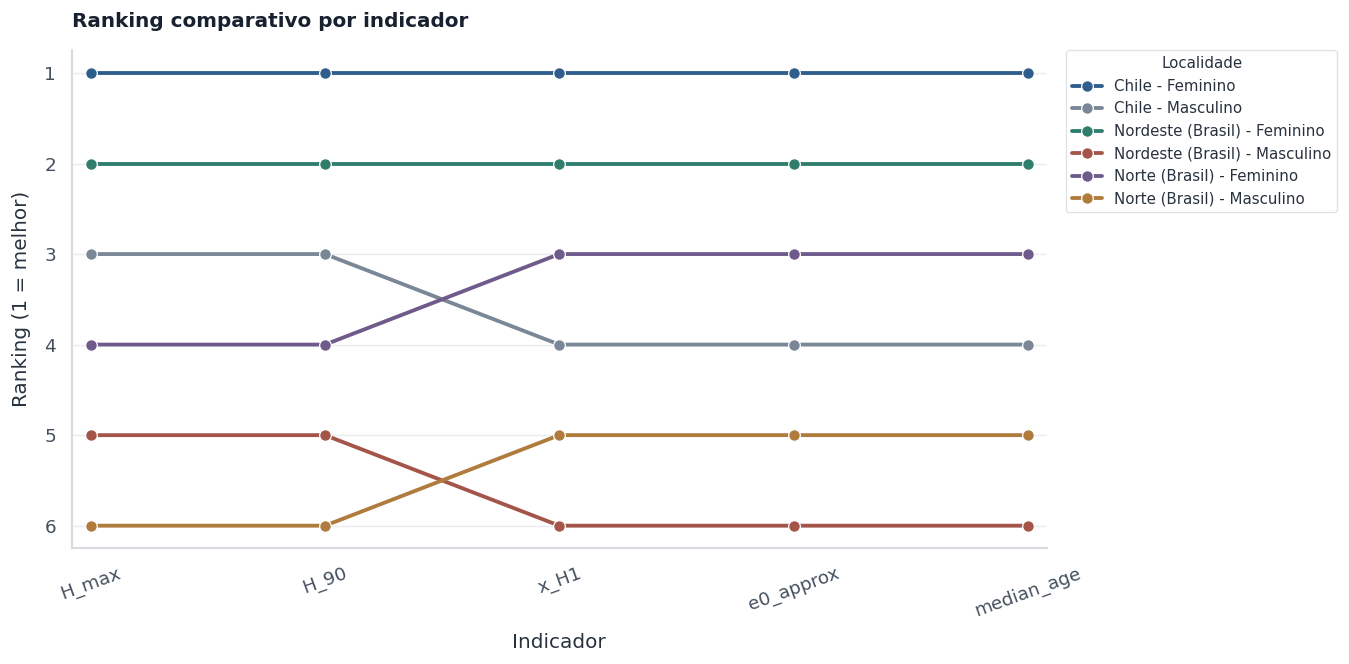

In [10]:
plot_indicator_heatmap_standardized(indicators)
plot_indicator_bars_brazil_regions(indicators)
plot_correlation_heatmap(correlations)
plot_indicator_scatter(indicators)
plot_indicator_rankings(rankings)